# Project Title: Global Supply Chain Disruption Analysis and Transportation Mode Prediction Using Decision Tree

## __Problem Statement__

- Global supply chains generate large amounts of logistics data, including information about shipment routes, lead times, costs, and delays. Selecting the appropriate transportation mode (such as air, sea, rail, or road) is important for efficient delivery and cost management. However, analyzing these factors manually can be difficult. Therefore, data analysis and machine learning techniques can be used to study supply chain data and build a predictive model that identifies the most suitable transportation mode based on shipment and logistics features.

### __Objectives__
- To analyze the global supply chain dataset and understand its structure through exploratory data analysis (EDA).
- To preprocess the data by handling missing values and encoding categorical variables.
- To build a machine learning model to predict the transportation mode using logistics-related features.
- To evaluate the model’s performance using appropriate evaluation metrics.

### Steps to be followed:
1. Import the required library
2. Load the data
3. Check for null values
4. Analyze the data column distribution
5. Balance the data
6. Encode of the full dataset
7. Split and train the dataset
8. Perform feature scaling on the dataset
9. Compile the model
10. Fit the model
11. Print the model
12. Evaluate the metrics


## Step 1: Import the Required Library
- Import the essential libraries for data manipulation and analysis, such as NumPy and Pandas, and use PyMySQL for database connectivity, LabelEncoder for data preprocessing, and Matplotlib for visualization

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV ,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.metrics import classification_report ,confusion_matrix,accuracy_score,precision_score,roc_curve,auc
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Data
- Load a CSV file named **loan_data.xlsx** into a Pandas DataFrame named **df**
- Display the initial few rows of the **df** DataFrame

In [56]:
df=pd.read_csv(r"C:\Users\kpasw\OneDrive\Desktop\Datasets\Data sets\global_supply_chain_disruption_v1.csv")
df

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD-525E3FA5,2024-10-14,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Consumer Electronics,7,8,8,0,On Time,NaN,0.58,8.1,3.38,7346.21,9299,Standard Shipping
9996,ORD-5E9DBD46,2024-09-10,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Textiles,7,10,7,0,On Time,NaN,0.37,5.5,2.34,4112.06,6003,Standard Shipping
9997,ORD-E6949429,2024-07-13,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.84,1.0,4.56,7346.20,7985,Standard Shipping
9998,ORD-29B9A2DA,2024-07-21,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Semiconductors,24,27,25,0,On Time,NaN,0.53,4.7,1.05,5810.94,7596,Standard Shipping


## Step 3:Data Cleaning and Preprocessing

In [57]:
df.describe()

,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500
std,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788
min,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000
25%,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000
50%,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000
75%,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000
max,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  object 
 1   Order_Date                10000 non-null  object 
 2   Origin_City               10000 non-null  object 
 3   Destination_City          10000 non-null  object 
 4   Route_Type                10000 non-null  object 
 5   Transportation_Mode       10000 non-null  object 
 6   Product_Category          10000 non-null  object 
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  object 
 12  Disruption_Event          1267 non-null   object 
 13  Geopolitical_Risk_Index   10000 non-null  float64
 14  Weather

In [59]:
df.isna().mean()*100

Order_ID                     0.00
Order_Date                   0.00
Origin_City                  0.00
Destination_City             0.00
Route_Type                   0.00
Transportation_Mode          0.00
Product_Category             0.00
Base_Lead_Time_Days          0.00
Scheduled_Lead_Time_Days     0.00
Actual_Lead_Time_Days        0.00
Delay_Days                   0.00
Delivery_Status              0.00
Disruption_Event            87.33
Geopolitical_Risk_Index      0.00
Weather_Severity_Index       0.00
Inflation_Rate_Pct           0.00
Shipping_Cost_USD            0.00
Order_Weight_Kg              0.00
Mitigation_Action_Taken      0.00
dtype: float64

In [60]:
df.drop(["Disruption_Event"],axis=1,inplace=True)

In [61]:
df.isna().sum()

Order_ID                    0
Order_Date                  0
Origin_City                 0
Destination_City            0
Route_Type                  0
Transportation_Mode         0
Product_Category            0
Base_Lead_Time_Days         0
Scheduled_Lead_Time_Days    0
Actual_Lead_Time_Days       0
Delay_Days                  0
Delivery_Status             0
Geopolitical_Risk_Index     0
Weather_Severity_Index      0
Inflation_Rate_Pct          0
Shipping_Cost_USD           0
Order_Weight_Kg             0
Mitigation_Action_Taken     0
dtype: int64

<Axes: >

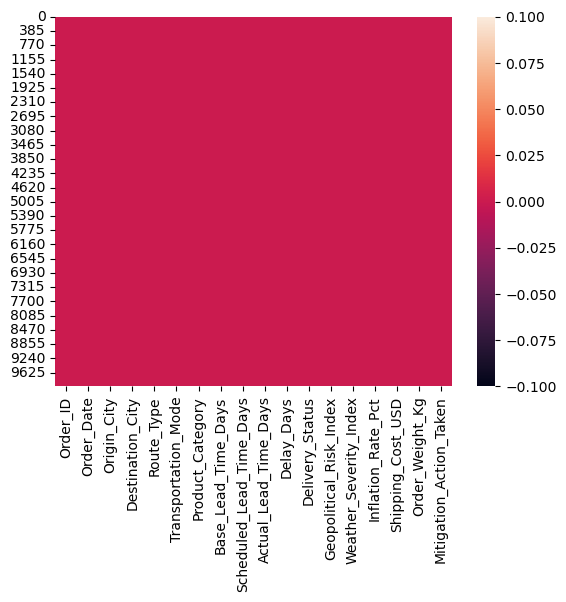

In [62]:
sns.heatmap(df.isna())

## Step 4: Exploratory Data Analysis (EDA)
- Visualizations are used to understand relationships between variables and battery health.

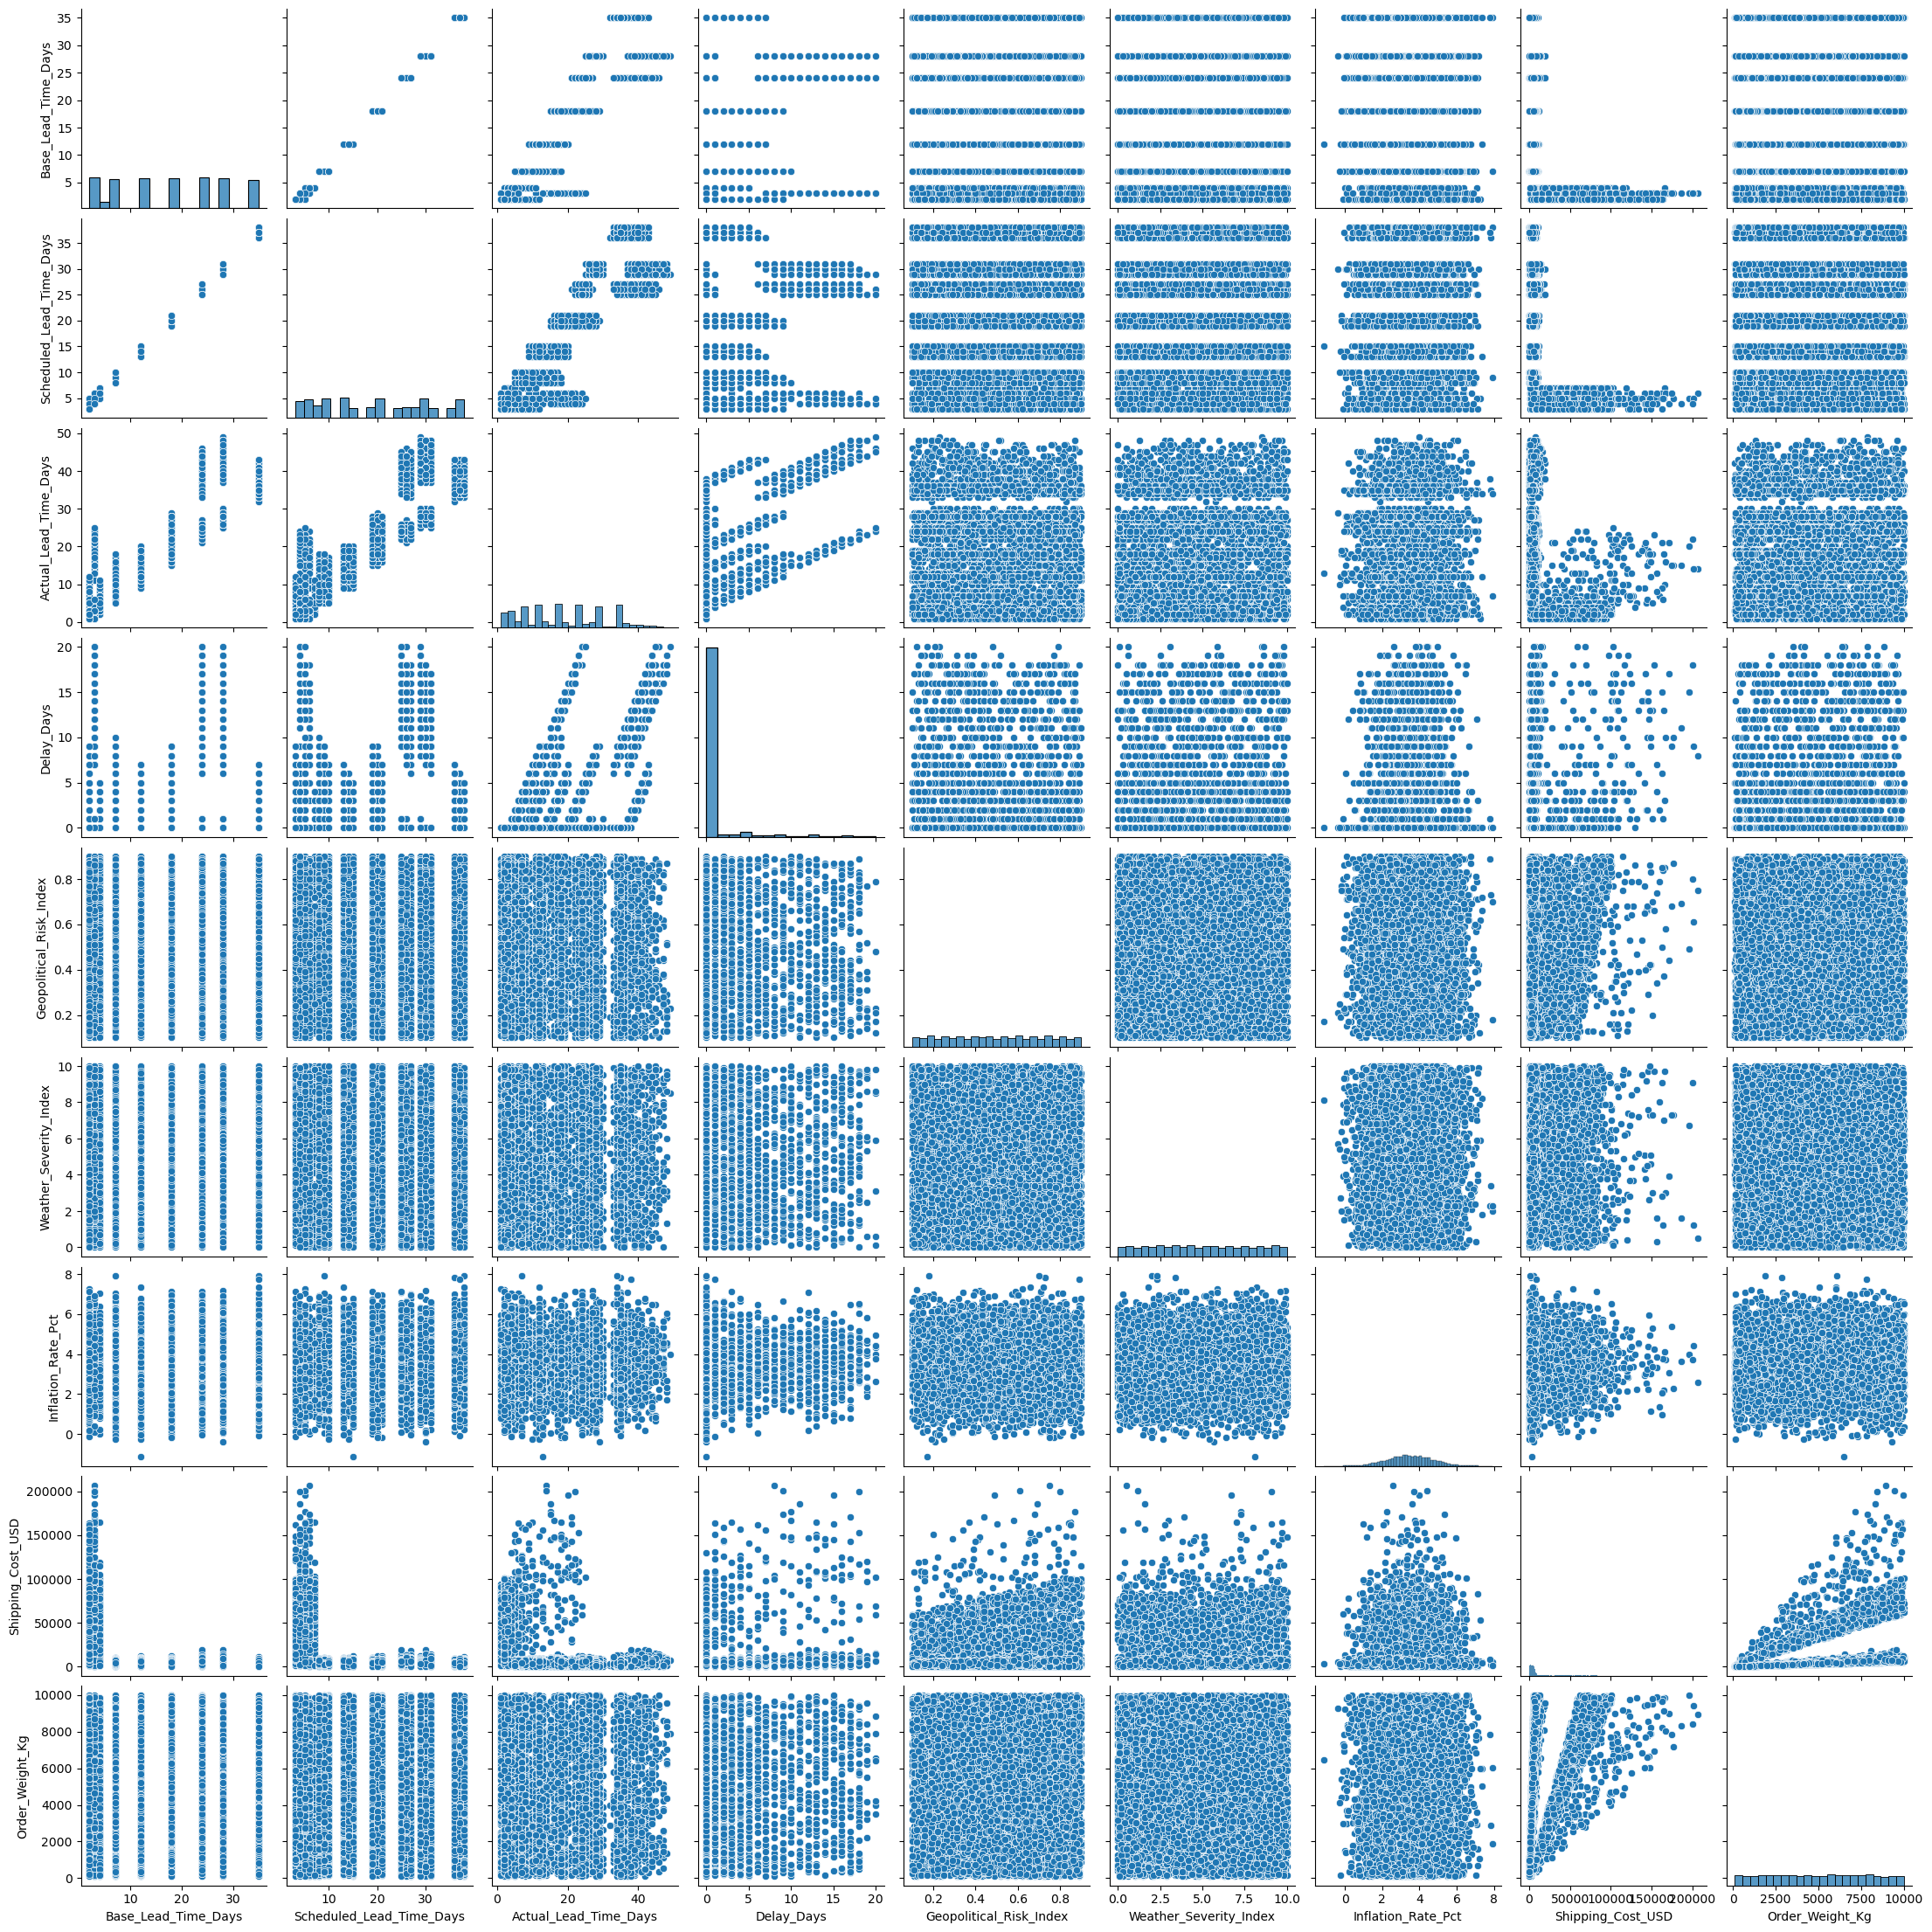

In [63]:
sns.pairplot(df)
plt.show()

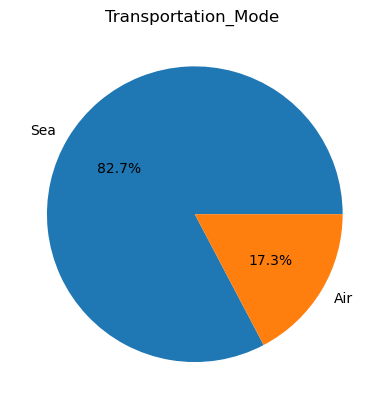

In [64]:
plt.figure()
df["Transportation_Mode"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Transportation_Mode ")
plt.ylabel("")
plt.show()

### Observation:
- Most shipments use Sea transportation (82.7%), while Air transportation is used less frequently (17.3%), indicating that sea is the dominant and more -commonly used mode in the dataset.

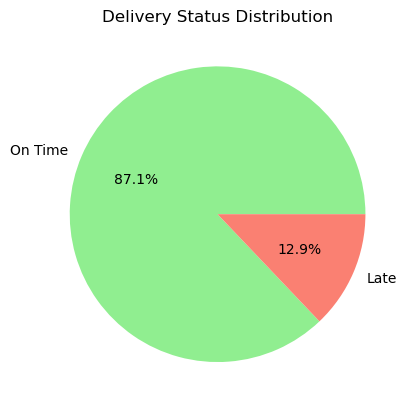

In [65]:
plt.figure()
df['Delivery_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['lightgreen','salmon','gold','lightskyblue']
)
plt.title('Delivery Status Distribution')
plt.ylabel('')
plt.show()


### Observation:
- Most deliveries are completed On Time (87.1%), while a small portion of shipments are Late (12.9%), indicating that the supply chain generally performs efficiently with timely deliveries.

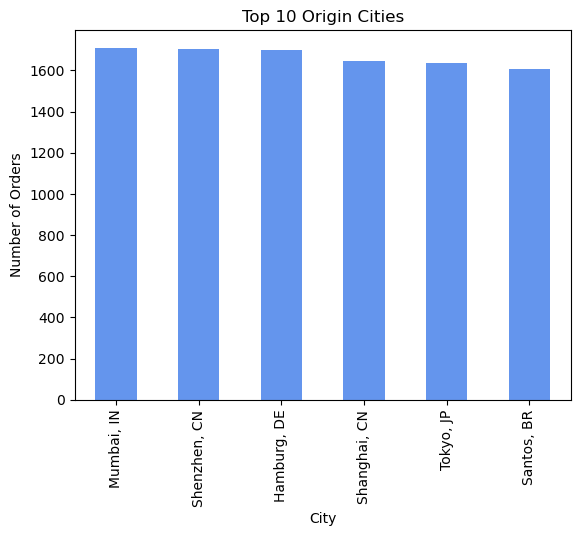

In [66]:
plt.figure()
df['Origin_City'].value_counts().head(10).plot.bar(color='cornflowerblue')
plt.title('Top 10 Origin Cities')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.show()


### Observation:
- The chart shows the top origin cities for shipments, with Mumbai, Shenzhen, and Hamburg having the highest number of orders.
- This indicates that these cities act as major supply chain hubs in the dataset.

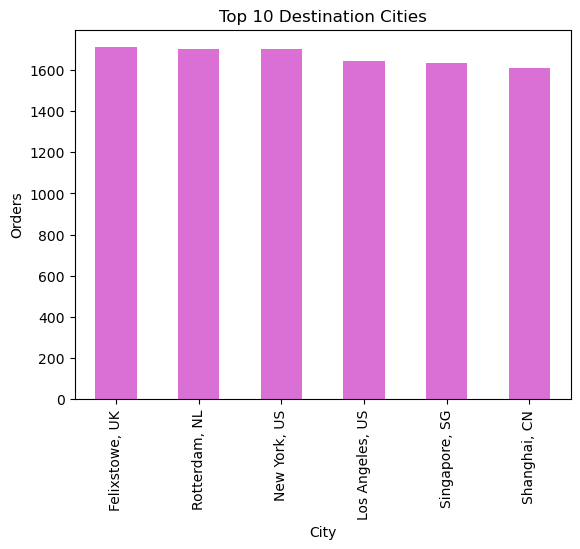

In [67]:
plt.figure()
df['Destination_City'].value_counts().head(10).plot.bar(color='orchid')
plt.title('Top 10 Destination Cities')
plt.xlabel('City')
plt.ylabel('Orders')
plt.show()


### Observation:
- The chart shows the top destination cities for shipments, with Felixstowe, Rotterdam, and New York receiving the highest number of orders, indicating that these cities are major delivery hubs in the supply chain network.

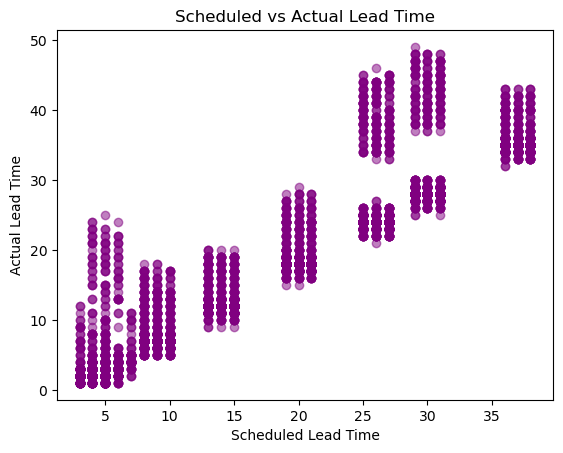

In [68]:
plt.figure()
plt.scatter(df['Scheduled_Lead_Time_Days'],
            df['Actual_Lead_Time_Days'],
            alpha=0.5, color='purple')
plt.title('Scheduled vs Actual Lead Time')
plt.xlabel('Scheduled Lead Time')
plt.ylabel('Actual Lead Time')
plt.show()


### Observation:
- The scatter plot shows a positive relationship between scheduled lead time and actual lead time. As the scheduled lead time increases, the actual lead time also tends to increase, indicating that longer planned deliveries generally take longer in reality as well.

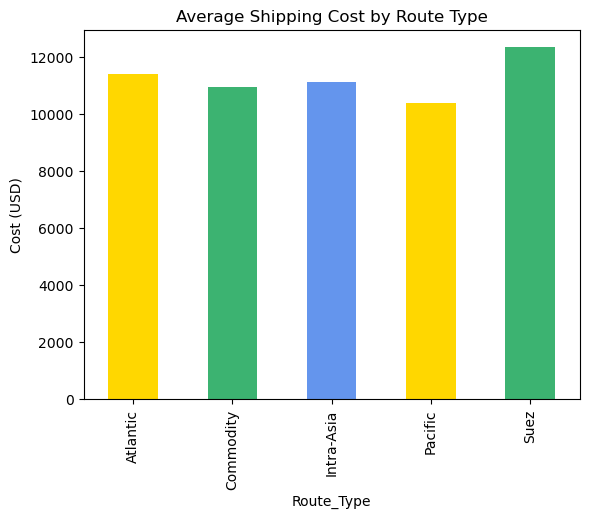

In [69]:
plt.figure()
df.groupby('Route_Type')['Shipping_Cost_USD'].mean().plot.bar(
    color=['gold','mediumseagreen','cornflowerblue']
)
plt.title('Average Shipping Cost by Route Type')
plt.ylabel('Cost (USD)')
plt.show()


### Observation:
- The bar chart shows that Suez routes have the highest average shipping cost, while Pacific routes have the lowest, indicating that shipping cost varies depending on the route type.

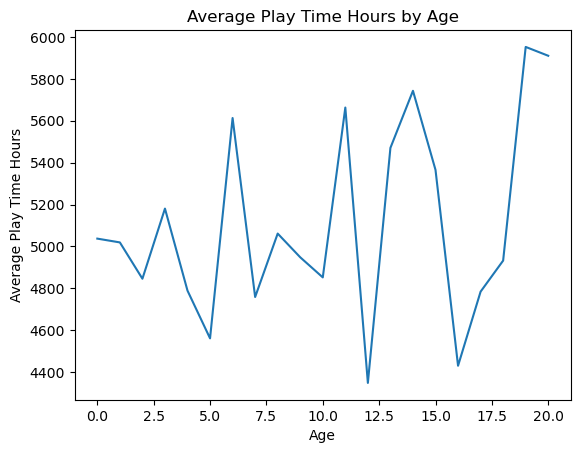

In [70]:
age_playtime = df.groupby("Delay_Days")["Order_Weight_Kg"].mean()

plt.figure()
plt.plot(age_playtime.index, age_playtime.values)
plt.title("Average Play Time Hours by Age")
plt.xlabel("Age")
plt.ylabel("Average Play Time Hours")
plt.show()


### Observation:
- The line chart shows fluctuations in the average values across delay days, indicating that the average order weight varies for different delay periods without a clear consistent trend.

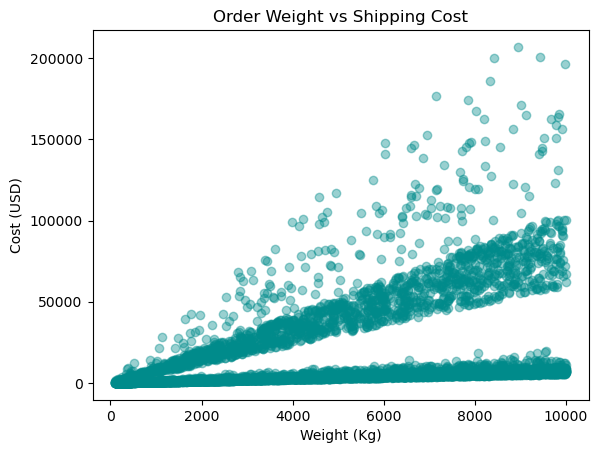

In [71]:
plt.figure()
plt.scatter(df['Order_Weight_Kg'], df['Shipping_Cost_USD'],
            alpha=0.4, color='darkcyan')
plt.title('Order Weight vs Shipping Cost')
plt.xlabel('Weight (Kg)')
plt.ylabel('Cost (USD)')
plt.show()


### Observation:
- The scatter plot shows a positive relationship between order weight and shipping cost, meaning shipping cost generally increases as the order weight increases.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  object 
 1   Order_Date                10000 non-null  object 
 2   Origin_City               10000 non-null  object 
 3   Destination_City          10000 non-null  object 
 4   Route_Type                10000 non-null  object 
 5   Transportation_Mode       10000 non-null  object 
 6   Product_Category          10000 non-null  object 
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  object 
 12  Geopolitical_Risk_Index   10000 non-null  float64
 13  Weather_Severity_Index    10000 non-null  float64
 14  Inflati

In [73]:
categorical_cols1 = df.select_dtypes(include=["object"]).columns
categorical_cols1

Index(['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City',
       'Route_Type', 'Transportation_Mode', 'Product_Category',
       'Delivery_Status', 'Mitigation_Action_Taken'],
      dtype='object')

In [74]:
categorical_cols2=categorical_cols1.drop(["Transportation_Mode"])
categorical_cols2

Index(['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City',
       'Route_Type', 'Product_Category', 'Delivery_Status',
       'Mitigation_Action_Taken'],
      dtype='object')

### Encoding Categorical Data
-This step prepares the categorical feature for model training.

In [75]:
label_encoder = LabelEncoder()
categorical_cols=categorical_cols2
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = label_encoder.fit_transform(df[col])

## Step 5: Feature–Target Separation

In [76]:
x=df.drop(columns=["Transportation_Mode"])
y=df["Transportation_Mode"]

### Traing and Testing the Features (Train-Test Splitting)
- Prevents overfitting
- Allows evaluation on unseen data

In [77]:
x_train,x_test,y_train,y_test=train_test_split(x, y,test_size=0.3,random_state=42)

### Feature Scaling (Standardization).

In [78]:
scaler=StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

## Step 6: Model Initialization & Model Training

In [79]:
tree = DecisionTreeClassifier()
tree.fit(x_train_scale, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Making Predictions
- model is going to predict the target values for the test dataset.
- These predictions will be used to evaluate the model’s performance.

In [80]:
y_pred = tree.predict(x_test_scale)

## Step 7: Model Evaluation
#### Model performance is evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

In [81]:
acc = accuracy_score(y_test, y_pred)
acc

1.0

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Air       1.00      1.00      1.00       535
         Sea       1.00      1.00      1.00      2465

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



# Conclusion:
- Sea transportation is the most commonly used mode for shipments in the dataset.
- Most deliveries are completed on time, indicating good supply chain efficiency.
- Certain cities act as major origin and destination hubs for shipments.
- Shipping costs vary by route type, with some routes being more expensive than others.
- There is a positive relationship between order weight and shipping cost.
- Overall, data analysis and machine learning help understand supply chain patterns and improve logistics decision-making.

In [83]:
from sklearn.model_selection import cross_val_score

In [84]:
score = cross_val_score(tree,x_train_scale,y_train, cv=5)
print(score)
print(score.mean()*100)

[1. 1. 1. 1. 1.]
100.0


In [85]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 535,    0],
       [   0, 2465]], dtype=int64)

In [86]:
from sklearn.metrics import roc_auc_score

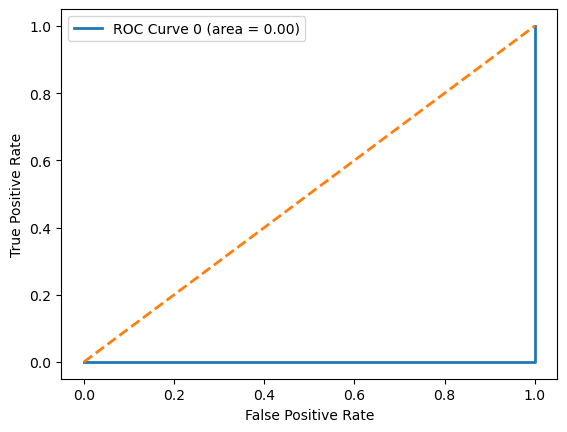

In [87]:
if len(set(y_test))>1:
    y_test_binarize = label_binarize(y_test, classes=tree.classes_)
    n_classes = y_test_binarize.shape[1]
    y_score = tree.predict_proba(x_test_scale)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarize[:, i], y_score[:, i])
        roc_auc[i] = roc_auc_score(y_test_binarize[:, i], y_score[:, i])
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw = 2, label='ROC Curve {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
    plt.plot([0, 1], [0,1], lw = 2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

In [88]:
cv_scores = cross_val_score(tree,x_train_scale,y_train, cv=5, scoring='accuracy')
print("CV Scores:",cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0


In [89]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [90]:
from sklearn.model_selection import GridSearchCV

In [91]:
dt= DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv =5, scoring='accuracy',n_jobs=-1)
grid_search.fit(x_train_scale, y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Accuracy: ", grid_search.best_score_)

best_grid_model = grid_search.best_estimator_

Best Parameters:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy:  1.0


In [92]:
from sklearn.model_selection import RandomizedSearchCV
random_search=RandomizedSearchCV(estimator=dt,param_distributions=param_grid,n_iter=20,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_search.fit(x_train_scale,y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [93]:
print("Best Parameters: ", random_search.best_params_)
print("Best CV Accuracy: ", random_search.best_score_)
best_random_model=random_search.best_estimator_

Best Parameters:  {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 5, 'criterion': 'entropy'}
Best CV Accuracy:  1.0
